# 04. BERT Sentiment Analysis

Applies transformer-based sentiment analysis to a stratified sample of USHMM reviews
and compares performance against VADER's two-channel model.

**Input:** `../Data/Processed/ushmm_tripadvisor_eng_vader.csv`  
**Output:** `../Data/Processed/ushmm_bert_sample.csv` (1,242 stratified reviews with bert_score)  
**Output:** `../Data/Processed/ushmm_full_with_bert.csv` (full 10,116 reviews; bert_score populated for sample rows only)

## Model
`distilbert-base-uncased-finetuned-sst-2-english` — a lightweight transformer
fine-tuned on the Stanford Sentiment Treebank (movie reviews).

**Limitation:** The model was not trained on Holocaust memorial content.
Its handling of atrocity language may still conflate emotional tone with
evaluative sentiment, similar to baseline VADER. The comparison with VADER
channels is therefore informative about the relative strengths of each approach.

## Sampling Strategy
BERT is computationally expensive at scale. Rather than running on all 10,116
reviews, we use a **stratified sample** of up to 350 reviews per star rating.
Because 1-star (n=75) and 2-star (n=117) reviews are rare, the total sample
is 1,242 — balanced across ratings to avoid the model being dominated by
5-star reviews (which represent 80% of the corpus).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
from transformers import pipeline

/home/ahlaad/miniconda3/envs/ushmm-analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
random.seed(7)
np.random.seed(7)
torch.manual_seed(7)

device = 0 if torch.cuda.is_available() else -1
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU — this will be slower")

GPU available: True
Device: NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
df = pd.read_csv("../Data/Processed/ushmm_tripadvisor_eng_vader.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(10116, 8)
['likes', 'rating', 'review_text', 'group_type', 'reviewer_location', 'emo_vader', 'eval_vader', 'emo_eval_bucket']


,likes,rating,review_text,group_type,reviewer_location,emo_vader,eval_vader,emo_eval_bucket
0,0,5,We spent four hours and could have spent eight...,COUPLES,"Bradley, Illinois",0.4201,0.4201,Emo+ / Eval+
1,1,5,We are Germans visiting this museum. Most of t...,FAMILY,"Heidelberg, Germany",0.7096,0.7096,Emo+ / Eval+
2,0,5,This museum is incredible and incredibly impor...,FAMILY,"Otsego, Minnesota",0.3875,0.3875,Emo+ / Eval+
3,0,5,I visited the Holocaust Museum in August 2024....,SOLO,"New York City, New York",-0.6712,0.0000,Mixed / Neutral
4,0,4,I learned so much. The place has a very sad vi...,FRIENDS,"Lewiston, New York",-0.5256,0.0754,Mixed / Neutral


## 1. Stratified Sample

In [4]:
base = df.dropna(subset=["review_text", "rating"]).copy()
base = base[base["review_text"].astype(str).str.strip().ne("")]

print("Rating distribution in full dataset:")
print(df["rating"].value_counts().sort_index())

# Stratified sample: up to 350 per star rating
# 1★ (75) + 2★ (117) + 3★ (350) + 4★ (350) + 5★ (350) = 1,242
N_PER_STAR = 350
parts = []
for r in sorted(base["rating"].unique()):
    n = min(N_PER_STAR, (base["rating"] == r).sum())
    parts.append(base[base["rating"] == r].sample(n=n, random_state=7))

sample = pd.concat(parts).sample(frac=1, random_state=7).reset_index(drop=True)
print(f"\nStratified sample size: {len(sample)}")
print("Sample rating distribution:")
print(sample["rating"].value_counts().sort_index())

Rating distribution in full dataset:
rating
1      75
2     117
3     419
4    1397
5    8108
Name: count, dtype: int64

Stratified sample size: 1242
Sample rating distribution:
rating
1     75
2    117
3    350
4    350
5    350
Name: count, dtype: int64


## 2. Run BERT

⚠️ This cell takes several minutes on CPU. On GPU it runs in under a minute.

In [5]:
clf = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

texts = sample["review_text"].astype(str).tolist()
preds = clf(texts, batch_size=32, truncation=True, max_length=256)
print(f"Predictions complete: {len(preds)} reviews scored")
print("Example prediction:", preds[0])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1012.83it/s]


Predictions complete: 1242 reviews scored
Example prediction: {'label': 'POSITIVE', 'score': 0.9997289776802063}


In [6]:
# Convert to signed score: POSITIVE → +score, NEGATIVE → -score
def signed_score(row):
    return row["score"] if row["label"] == "POSITIVE" else -row["score"]

sample["bert_score"] = [signed_score(p) for p in preds]

print("BERT score distribution:")
print(sample["bert_score"].describe().round(3))

BERT score distribution:
count    1242.000
mean        0.130
std         0.963
min        -1.000
25%        -0.994
50%         0.952
75%         0.999
max         1.000
Name: bert_score, dtype: float64


## 3. BERT vs Star Rating

In [7]:
print("Mean BERT score by star rating:")
print(sample.groupby("rating")["bert_score"].mean().round(3))

print("\nCorrelation (BERT vs rating):",
      sample[["bert_score", "rating"]].corr().iloc[0, 1].round(3))

Mean BERT score by star rating:
rating
1   -0.789
2   -0.803
3   -0.373
4    0.466
5    0.805
Name: bert_score, dtype: float64

Correlation (BERT vs rating): 0.603


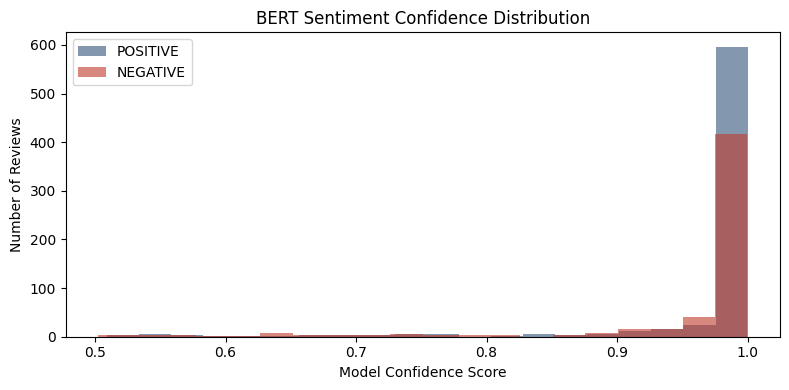

Mean confidence by label:
label
NEGATIVE    0.962
POSITIVE    0.972
Name: score, dtype: float64


In [8]:
# Confidence score distribution
pred_df = pd.DataFrame(preds)

fig, ax = plt.subplots(figsize=(8, 4))
for sentiment, color in [("POSITIVE", "#305479"), ("NEGATIVE", "#c0392b")]:
    ax.hist(pred_df[pred_df["label"] == sentiment]["score"],
            bins=20, alpha=0.6, label=sentiment, color=color)
ax.set_xlabel("Model Confidence Score")
ax.set_ylabel("Number of Reviews")
ax.set_title("BERT Sentiment Confidence Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("../Outputs/Figures/bert_confidence_distribution.png", dpi=150)
plt.show()

print("Mean confidence by label:")
print(pred_df.groupby("label")["score"].mean().round(3))

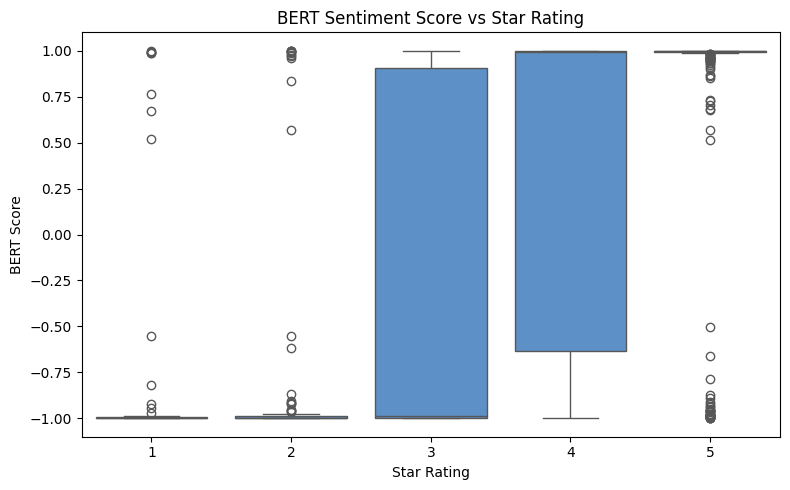

In [9]:
# Boxplot: BERT score vs star rating
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="rating", y="bert_score", data=sample, color="#4a90d9", ax=ax)
ax.set_title("BERT Sentiment Score vs Star Rating")
ax.set_xlabel("Star Rating")
ax.set_ylabel("BERT Score")
plt.tight_layout()
plt.savefig("../Outputs/Figures/bert_score_by_rating.png", dpi=150)
plt.show()

## 4. BERT vs VADER Comparison

Merge BERT scores back to the full dataframe to compare
all three sentiment measures on the same reviews.

In [10]:
# Merge BERT scores into the full df on review_text
sample_small = sample[["review_text", "bert_score"]].drop_duplicates(subset=["review_text"])

sample_eval = sample_small.merge(
    df[["review_text", "emo_vader", "eval_vader", "rating"]],
    on="review_text",
    how="left"
)

print("Correlation matrix (BERT sample):")
print(sample_eval[["bert_score", "emo_vader", "eval_vader", "rating"]].corr().round(3))

Correlation matrix (BERT sample):
            bert_score  emo_vader  eval_vader  rating
bert_score       1.000      0.249       0.348   0.603
emo_vader        0.249      1.000       0.909   0.163
eval_vader       0.348      0.909       1.000   0.319
rating           0.603      0.163       0.319   1.000


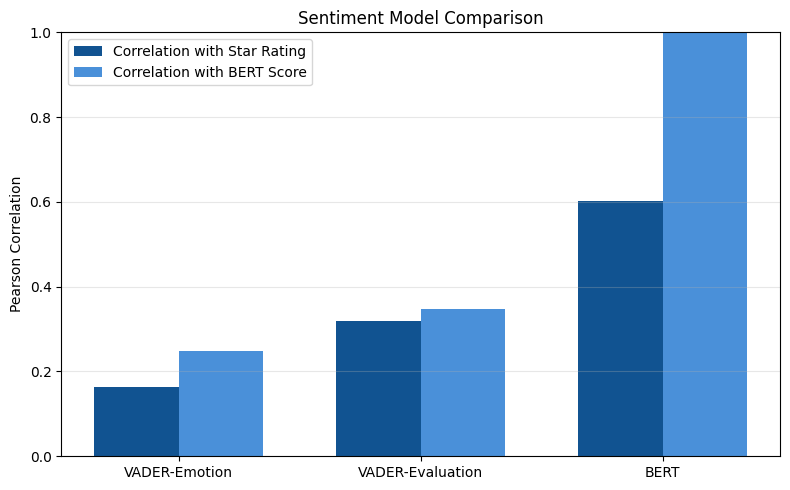

In [11]:
# Correlation bar chart — computed from data, not hardcoded
corr_rating = sample_eval[["bert_score", "emo_vader", "eval_vader", "rating"]].corr()["rating"]
corr_bert = sample_eval[["bert_score", "emo_vader", "eval_vader", "rating"]].corr()["bert_score"]

labels = ["VADER-Emotion", "VADER-Evaluation", "BERT"]
keys = ["emo_vader", "eval_vader", "bert_score"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [corr_rating[k] for k in keys], width,
       label="Correlation with Star Rating", color="#115391")
ax.bar(x + width/2, [corr_bert[k] for k in keys], width,
       label="Correlation with BERT Score", color="#4a90d9")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Pearson Correlation")
ax.set_title("Sentiment Model Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../Outputs/Figures/bert_vader_comparison.png", dpi=150)
plt.show()

## 5. Memorial Paradox Cases

Reviews where BERT and star rating disagree — the clearest
empirical evidence of the memorial paradox.

In [12]:
pos = sample["bert_score"] >= 0.2
neg = sample["bert_score"] <= -0.2
hi = sample["rating"] >= 4
lo = sample["rating"] <= 2

print("High-star (4-5★) but BERT negative:",
      f"{((hi) & (neg)).sum()} reviews ({((hi) & (neg)).mean()*100:.1f}%)")
print("Low-star (1-2★) but BERT positive:",
      f"{((lo) & (pos)).sum()} reviews ({((lo) & (pos)).mean()*100:.1f}%)")

High-star (4-5★) but BERT negative: 126 reviews (10.1%)
Low-star (1-2★) but BERT positive: 19 reviews (1.5%)


In [13]:
def show_bert_examples(mask, k=3, title=""):
    print(f"\n{title}")
    sub = sample.loc[mask, ["rating", "group_type", "reviewer_location",
                             "bert_score", "review_text"]].head(k)
    for _, r in sub.iterrows():
        print(f"  ★{int(r['rating'])} | {r['group_type']} | {r['reviewer_location']}")
        print(f"  bert={r['bert_score']:.2f}")
        print(f"  {str(r['review_text'])[:300]}...")

show_bert_examples(
    (sample["rating"] >= 4) & (sample["bert_score"] < 0),
    title="High-star reviews scored negative by BERT (Memorial Paradox)"
)
show_bert_examples(
    (sample["rating"] <= 2) & (sample["bert_score"] > 0),
    title="Low-star reviews scored positive by BERT"
)


High-star reviews scored negative by BERT (Memorial Paradox)
  ★4 | FAMILY | Pittsburgh, Pennsylvania
  bert=-1.00
  I have never seen so many people walking through a museum so quietly. Still so hard to imagine all the atrocities. There was a lot of reading required so while I did not think my 11 year old was too young, she did lose interest in reading all the exhibits....
  ★4 | COUPLES | nan
  bert=-1.00
  Must see for everyone just to see how it all developed over more than a decade before the "final solution" was actually put into practice. How a society and the world in general really set the stage for all this to occur causes one to think about how we go about things in the modern world.

The only...
  ★4 | FAMILY | Orange County, California
  bert=-0.98
  Emotionally this was the most somber experience of my D.C. trip but as the saying inscribed in the museum we must never forget so that such tragedy never repeats itself.  Be prepared for extremely long lines and crowds, give 

## 6. Export

In [14]:
# Save the stratified BERT sample (1,242 rows)
sample.to_csv("../Data/Processed/ushmm_bert_sample.csv", index=False)
print(f"Saved BERT sample: {len(sample)} rows → ../Data/Processed/ushmm_bert_sample.csv")

# Save full dataset with bert_score populated where available
df["bert_score"] = np.nan
df.loc[sample.index, "bert_score"] = sample["bert_score"].values
df.to_csv("../Data/Processed/ushmm_full_with_bert.csv", index=False)
print(f"Saved full dataset: {len(df)} rows → ../Data/Processed/ushmm_full_with_bert.csv")
print(f"bert_score populated for {df['bert_score'].notna().sum()} rows")

Saved BERT sample: 1242 rows → ../Data/Processed/ushmm_bert_sample.csv
Saved full dataset: 10116 rows → ../Data/Processed/ushmm_full_with_bert.csv
bert_score populated for 1242 rows
